# Purpose of Notebook

The purpose of this notebook is to offer an example answer to the guided project for the Optimizing Models course. The reference model will be the same for all students, but any other models are constructed by the student. Results may vary.

The data is from [UCI ML Repository](https://archive.ics.uci.edu/dataset/162/forest+fires) it is a difficult regression task, where the aim is to predict the burned area of forest fires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
fires = pd.read_csv('fires.csv')
fires.head()

fires_reference = fires[["wind", "temp", "area"]].dropna()
reference_X = fires_reference[["wind", "temp"]]
reference = LinearRegression()

In [3]:
for col in fires.columns:
    print(f' This {col} column has {fires[col].isna().sum()} missing values')

 This Unnamed: 0 column has 0 missing values
 This X column has 0 missing values
 This Y column has 0 missing values
 This month column has 0 missing values
 This day column has 0 missing values
 This FFMC column has 48 missing values
 This DMC column has 21 missing values
 This DC column has 43 missing values
 This ISI column has 2 missing values
 This temp column has 21 missing values
 This RH column has 30 missing values
 This wind column has 35 missing values
 This rain column has 32 missing values
 This area column has 0 missing values


## Data Preprocessing

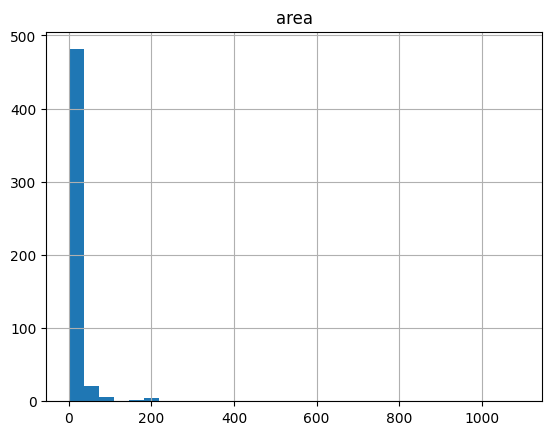

In [4]:
fires.hist('area', bins=30)
plt.show()

The data is showing high skeweness, log transformation can do the job of spreading the data.

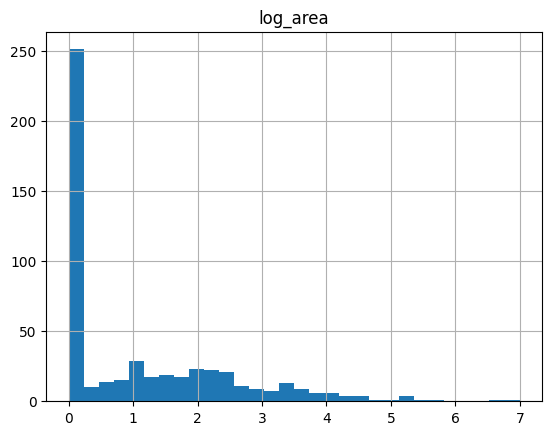

In [5]:
fires['log_area'] = np.log(fires['area'] + 1)

fires.hist(column='log_area', bins=30)
plt.show()

It does not produce a bell shaped curve but it spreads the data more than it was before the transformation.

In [6]:
fires['month'].unique()

array(['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan',
       'dec', 'may', 'nov'], dtype=object)

In [7]:
def is_summer(month):
    if month in ['jun', 'jul', 'aug']:
        return 1
    else:
        return 0
    
fires['summer'] = [is_summer(col) for col in fires['month']]

fires.head()

,Unnamed: 0,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,log_area,summer
0,1,7,5,mar,fri,86.2,26.2,94.3,5.1,NaN,51.0,6.7,0.0,0.0,0.0,0
1,2,7,4,oct,tue,90.6,NaN,669.1,6.7,18.0,33.0,0.9,0.0,0.0,0.0,0
2,3,7,4,oct,sat,90.6,43.7,NaN,6.7,14.6,33.0,1.3,0.0,0.0,0.0,0
3,4,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97.0,4.0,0.2,0.0,0.0,0
4,5,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99.0,NaN,0.0,0.0,0.0,0


In [8]:
from sklearn.impute import KNNImputer

imp = KNNImputer(missing_values=np.nan, n_neighbors=3)

fires_missing = fires[fires.columns[5:13]]
imputed = pd.DataFrame(imp.fit_transform(fires_missing), 
                       columns=fires.columns[5:13])
imputed

,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,86.2,26.200000,94.300000,5.1,16.6,51.0,6.700000,0.0
1,90.6,56.433333,669.100000,6.7,18.0,33.0,0.900000,0.0
2,90.6,43.700000,470.833333,6.7,14.6,33.0,1.300000,0.0
3,91.7,33.300000,77.500000,9.0,8.3,97.0,4.000000,0.2
4,89.3,51.300000,102.200000,9.6,11.4,99.0,4.333333,0.0
...,...,...,...,...,...,...,...,...
512,81.6,56.700000,665.600000,1.9,27.8,32.0,2.700000,0.0
513,81.6,56.700000,665.600000,1.9,21.9,71.0,5.800000,0.0
514,81.6,56.700000,665.600000,1.9,21.2,70.0,6.700000,0.0
515,94.4,146.000000,614.700000,11.3,25.6,42.0,4.000000,0.0


Now that we have filled all the missing columns, we can check if there are any outliers in the data.

In [9]:
imputed.columns

Index(['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain'], dtype='object')

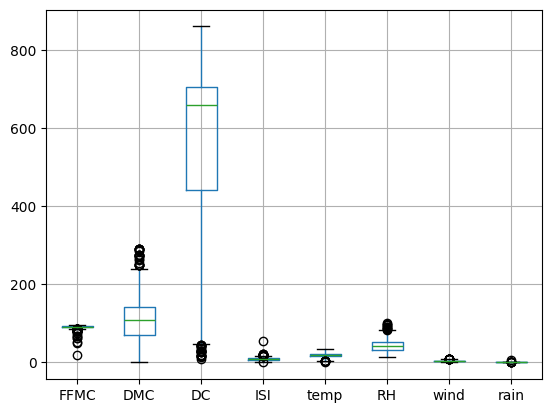

In [10]:
imputed.boxplot(['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain'])
plt.show()

from the above diagram, it shows that there a few columns that contain outliers. Let's try to calculate and what see what we can find out.

In [11]:
imputed_clean = imputed.copy()

for col in imputed_clean.columns:
    quartiles = np.percentile(imputed_clean[col], [25, 50, 75])
    iqr = quartiles[2] - quartiles[0]
    lower_bound = quartiles[0] - (1.5 * iqr)
    upper_bound = quartiles[2] + (1.5 * iqr)
    outliers = sum((imputed_clean[col] < lower_bound) | (imputed_clean[col] > upper_bound))

    print(f"The {col} column has {outliers} according to the boxplot method.")

    mask = (imputed_clean[col] >= lower_bound) & (imputed_clean[col] <= upper_bound)
    

    imputed_clean = imputed_clean[mask]

print('*' * 40)
print(f"Original rows: {imputed.shape[0]}")
print(f"Cleaned rows: {imputed_clean.shape[0]}")

imputed_clean.head()

The FFMC column has 53 according to the boxplot method.
The DMC column has 25 according to the boxplot method.
The DC column has 57 according to the boxplot method.
The ISI column has 10 according to the boxplot method.
The temp column has 9 according to the boxplot method.
The RH column has 7 according to the boxplot method.
The wind column has 1 according to the boxplot method.
The rain column has 6 according to the boxplot method.
****************************************
Original rows: 517
Cleaned rows: 349


,FFMC,DMC,DC,ISI,temp,RH,wind,rain
1,90.6,56.433333,669.100000,6.7,18.0,33.0,0.9,0.0
2,90.6,43.700000,470.833333,6.7,14.6,33.0,1.3,0.0
5,92.3,85.300000,488.000000,14.7,22.2,29.0,5.4,0.0
6,92.3,88.900000,495.600000,8.5,24.1,27.0,3.1,0.0
8,91.0,129.500000,692.600000,7.0,13.1,63.0,5.4,0.0


The data contains outliers, since large fires are rare and extreme events, we will retain these outliers in our dataset so the model can learn high-impact conditions.

Let's visualize some of these columns that are outliers

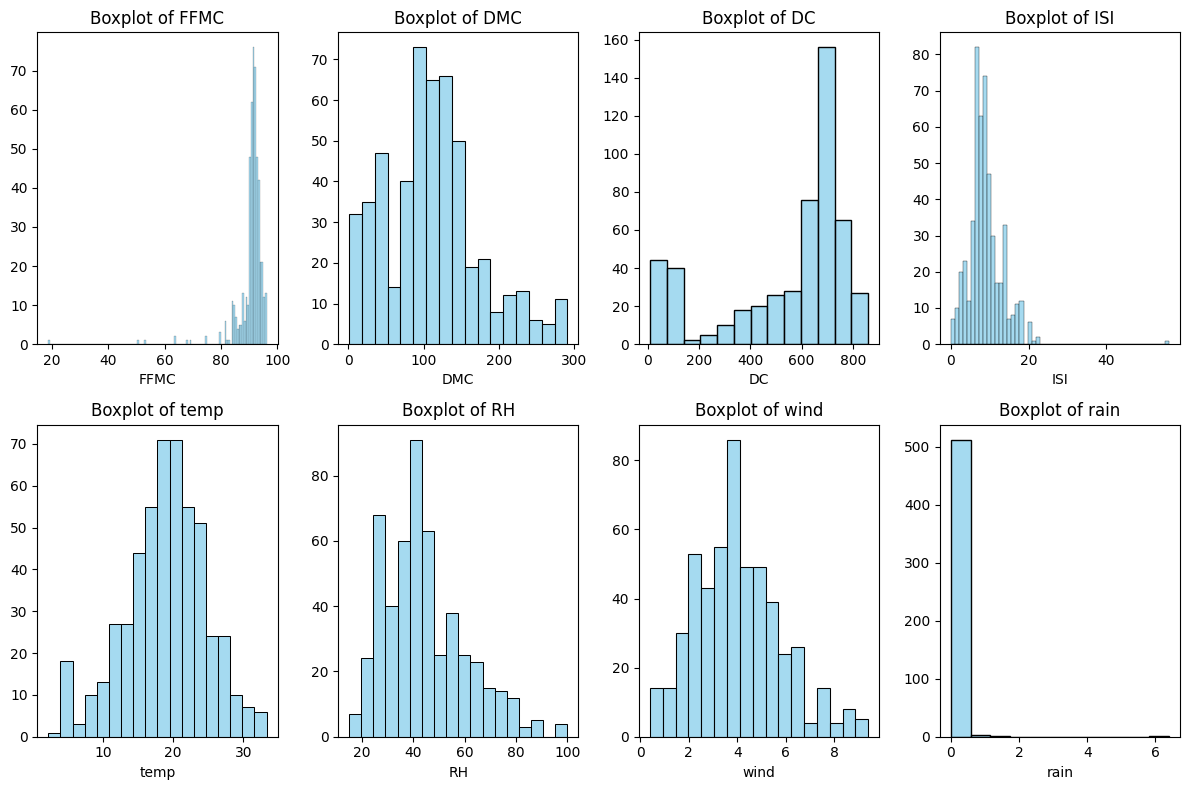

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))

axes = axes.flatten()

for i, col in enumerate(imputed):
    sns.histplot(data=imputed, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

We can see that there are no extreme values that standout from the data.

In [13]:
imputed_clean.isna().sum()

FFMC    0
DMC     0
DC      0
ISI     0
temp    0
RH      0
wind    0
rain    0
dtype: int64

In [14]:
imputed_clean.shape

(349, 8)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(imputed) # this returns a numpy array
scaled = pd.DataFrame(scaled, columns=fires.columns[5:13])

final = pd.concat([scaled, fires['summer'].reindex(scaled.index)], axis=1)

final

,FFMC,DMC,DC,ISI,temp,RH,wind,rain,summer
0,-0.812283,-1.335942,-1.846711,-0.860187,-0.398187,0.418726,1.514159,-0.073268,0
1,-0.010735,-0.859009,0.509582,-0.508736,-0.155493,-0.715565,-1.761003,-0.073268,0
2,-0.010735,-1.059878,-0.303178,-0.508736,-0.744894,-0.715565,-1.535130,-0.073268,0
3,0.189652,-1.223939,-1.915580,-0.003526,-1.837021,3.317471,-0.010485,0.603155,0
4,-0.247556,-0.939988,-1.814327,0.128267,-1.299625,3.443503,0.177742,-0.073268,0
...,...,...,...,...,...,...,...,...,...
512,-1.650265,-0.854803,0.495235,-1.563087,1.543370,-0.778581,-0.744573,-0.073268,1
513,-1.650265,-0.854803,0.495235,-1.563087,0.520585,1.679050,1.005944,-0.073268,1
514,-1.650265,-0.854803,0.495235,-1.563087,0.399238,1.616034,1.514159,-0.073268,1
515,0.681511,0.553912,0.286579,0.501683,1.161993,-0.148419,-0.010485,-0.073268,1


## Featrure Selection

In [16]:
from sklearn.feature_selection import SequentialFeatureSelector

y = fires['log_area'].reindex(scaled.index)
sfs_model = LinearRegression()
forward = SequentialFeatureSelector(estimator=sfs_model, n_features_to_select=3, direction='forward')

forward.fit(final, y)
forward_features = list(forward.get_feature_names_out()) + ['temp']
print(forward_features)

['FFMC', 'DC', 'wind', 'temp']


In [17]:
from sklearn.feature_selection import SequentialFeatureSelector

backward = SequentialFeatureSelector(estimator=sfs_model, n_features_to_select=3, direction='backward')
backward.fit(final, y)

backward_features = backward.get_feature_names_out()
print(backward_features)

['FFMC' 'DC' 'wind']


## Training a model

We have a reference model and we have selected features

In [18]:
f_model = LinearRegression()
b_model = LinearRegression()

In [19]:
from sklearn.linear_model import RidgeCV, LassoCV

ridge = RidgeCV(alphas=np.linspace(10, 10000, num=1000))
lasso = LassoCV(alphas=np.linspace(10, 10000, num=1000))

ridge.fit(final, y)
lasso.fit(final, y)

print('Ridge tuning parameter', ridge.alpha_)
print('Lasso Tuning parameter', lasso.alpha_)

print('Ridge coefficients', ridge.coef_)
print('Lasso coefficients', lasso.coef_)

Ridge tuning parameter 1370.0
Lasso Tuning parameter 10000.0
Ridge coefficients [ 0.0131243   0.02008609  0.02006783 -0.01075404  0.01298191 -0.0149137
  0.02674036  0.00817012 -0.01457418]
Lasso coefficients [ 0.  0.  0. -0.  0. -0.  0.  0. -0.]


The LASSO tuning parameter expects a larger tuning parameter since it is sitting on exactly `10000`.

We'll try to only use ridge in this case.

In [20]:
ridge = RidgeCV(alphas=np.linspace(1000, 1500, num=1000))
ridge.fit(final, y)
print('Ridge Tuning parameter', ridge.alpha_)

Ridge Tuning parameter 1371.3713713713714


In [21]:
from sklearn.model_selection import cross_val_score 

reference_cv = cross_val_score(reference, final[["wind", "temp"]], y, cv = 5, scoring = "neg_mean_squared_error")
forward_cv = cross_val_score(f_model, final[forward_features], y, cv=5, scoring='neg_mean_squared_error')
backward_cv = cross_val_score(b_model, final[backward_features], y, cv=5, scoring='neg_mean_squared_error')
ridge_cv = cross_val_score(ridge, final, y, cv = 5, scoring = "neg_mean_squared_error")

In [22]:
print("Reference Model, Avg Test MSE: ", np.mean(reference_cv), " SD: ", np.std(reference_cv))
print("Forward Model, Avg Test MSE: ", np.mean(forward_cv), " SD: ", np.std(forward_cv))
print("Backward Model, Avg Test MSE: ", np.mean(backward_cv), " SD: ", np.std(backward_cv))
print("Ridge Model, Avg Test MSE: ", np.mean(ridge_cv), " SD: ", np.std(ridge_cv))

Reference Model, Avg Test MSE:  -2.204650013004116  SD:  1.060040355378637
Forward Model, Avg Test MSE:  -2.238030557820237  SD:  1.066778758179568
Backward Model, Avg Test MSE:  -2.173227096397195  SD:  1.0023876873452748
Ridge Model, Avg Test MSE:  -2.196754531261845  SD:  1.0390316623530433


## Examining model weakness

To do this we will visualize how the model predictions compare against the actual observed values in the data

In [23]:
best_model = LinearRegression()
best_model.fit(final[forward_features], y)
prediction = best_model.predict(final[forward_features])

df_plot = pd.DataFrame({
    'actual': np.exp(y),        # Don't use the tranformed target variable
    'prediction': prediction,
    'residual': np.exp(y) - prediction,
})

In [24]:
minimum = min(y.min(), prediction.min())
maximum = max(y.max(), prediction.max())

print(minimum)
print(maximum)

0.0
6.995619625423205


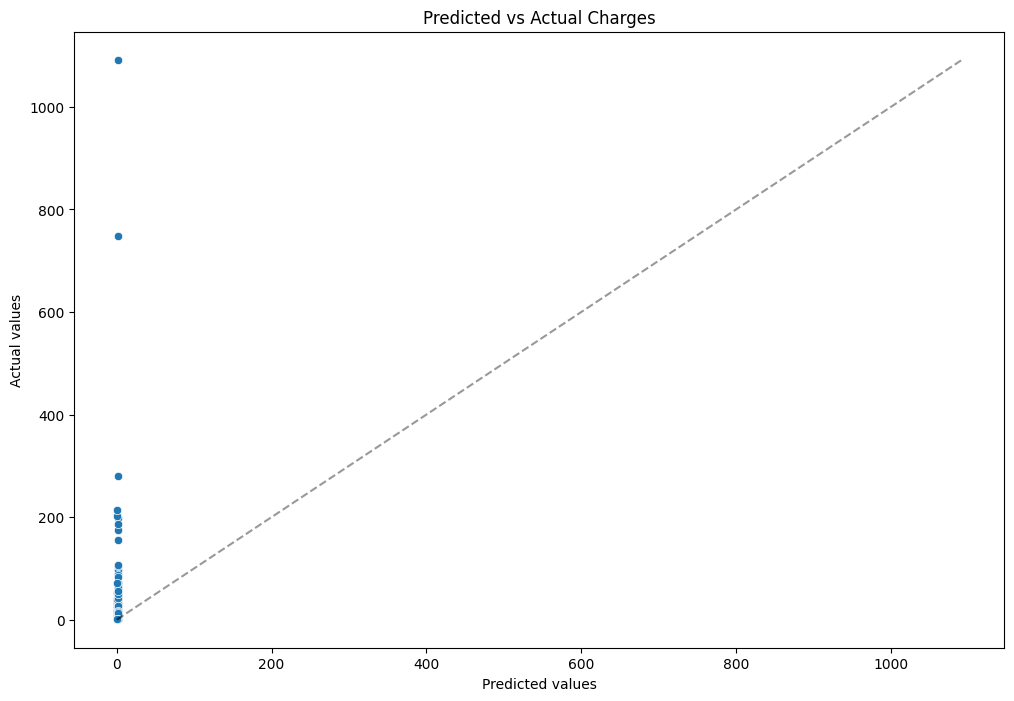

In [25]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_plot, x='prediction', y='actual')
plt.title('Predicted vs Actual Charges')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')

plt.plot([0, 7], [0, 7], 'k--', alpha=0.4)
max_val = max(df_plot['prediction'].max(), df_plot['actual'].max())
min_val = min(df_plot['prediction'].min(), df_plot['actual'].min())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, label='Ideal Prediction')

plt.show()

We should also try non-linear models such as the splines and polynomial models. We may also see good performances from other types of models such as decision tree or Random forest.

The UCI repository notes that this is a "difficult regression task," and that was reflected in the test performance of the models in the solution. Many of the models that we've learned about require assumptions about the data that just aren't satisfied. 

## Lets make Polynomial models

We will use this to check if there any non-linear nature, if there's an improvement in the MSE the data is non-linear

In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = imputed[forward_features]
y = fires['log_area']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2, include_bias=False)

quad_X_train = poly.fit_transform(X_train[forward_features])
quad_X_test = poly.fit_transform(X_test[forward_features])

linear = LinearRegression()
quadratic = LinearRegression()

linear.fit(X_train, y_train)
quadratic.fit(quad_X_train, y_train)

linear_mse = mean_squared_error(y_test, linear.predict(X_test))
quadratic_mse = mean_squared_error(y_test, quadratic.predict(quad_X_test))

print(linear_mse)
print(quadratic_mse)

2.167918585410401
2.104957044599471


In [27]:
# Convert your predictions and actual test answers back to real hectares
predictions_hectares = np.expm1(quadratic.predict(quad_X_test))
y_test_hectares = np.expm1(y_test)

# Print a comparison of the first 5 rows to see how it looks
comparison_df = pd.DataFrame({
    'Actual (Hectares)': y_test_hectares,
    'Predicted (Hectares)': predictions_hectares
})
print(comparison_df.head())

     Actual (Hectares)  Predicted (Hectares)
304               0.00              1.953621
501               0.00              1.980082
441               1.23              2.813879
153               1.46              2.016894
503               1.95              2.919021


In [28]:
# Calculate MSE using the values that were converted back to hectares
true_mse_hectares = mean_squared_error(y_test_hectares, predictions_hectares)

print(f"Log-scale MSE: {quadratic_mse}") 
print(f"True MSE in Hectares: {true_mse_hectares}")

Log-scale MSE: 2.104957044599471
True MSE in Hectares: 12085.645476386064


In [29]:
print("Reference Model, Avg Test MSE: ", np.mean(reference_cv), " SD: ", np.std(reference_cv))

Reference Model, Avg Test MSE:  -2.204650013004116  SD:  1.060040355378637


### Final Conclusion & Insights

1. **The Core Drivers of Fire Devastation:** Sequential Feature Selection isolated **FFMC** (Fine Fuel Moisture Code), **DC** (Drought Code), and **wind** as the most critical predictors of burned area. This demonstrates that fire scale is heavily driven by a combination of immediate ignition readiness (surface litter moisture), cumulative seasonal drought (deep organic soil dryness), and atmospheric oxygen delivery.

2. **The Non-Linear Reality:** Standard linear combinations failed to capture fire patterns effectively (Test MSE: 2.167).Upgrading to a Quadratic Polynomial model dropped our Log-scale MSE to 2.104. This improvement proves that environmental variables do not scale linearly with fire risk; rather, once drought index or wind speed crosses specific physical thresholds, fire growth accelerates exponentially.

3. **Operational Impact:** While our Log-scale predictions look stable, our True scale evaluation shows an MSE of 12,085.64 Hectares.This massive variance indicates that while we can reliably flag *high-risk days* based on FFMC and Wind thresholds , precisely predicting the exact size of an uncontrolled extreme event remains highly volatile—fully aligning with the UCI repository's classification of this dataset as a highly complex regression task.